X data types: density                                 float64
band_gap                                float64
formation_energy                        float64
poissons_ratio                          float64
ehull                                   float64
MagpieData mean AtomicWeight            float64
MagpieData avg_dev AtomicWeight         float64
MagpieData range AtomicWeight           float64
MagpieData mean Number                  float64
MagpieData avg_dev Number               float64
MagpieData range Number                 float64
MagpieData mean Electronegativity       float64
MagpieData avg_dev Electronegativity    float64
MagpieData range Electronegativity      float64
MagpieData mean MeltingT                float64
MagpieData avg_dev MeltingT             float64
MagpieData range MeltingT               float64
MagpieData mean CovalentRadius          float64
MagpieData avg_dev CovalentRadius       float64
MagpieData range CovalentRadius         float64
dtype: object
Model Perfor

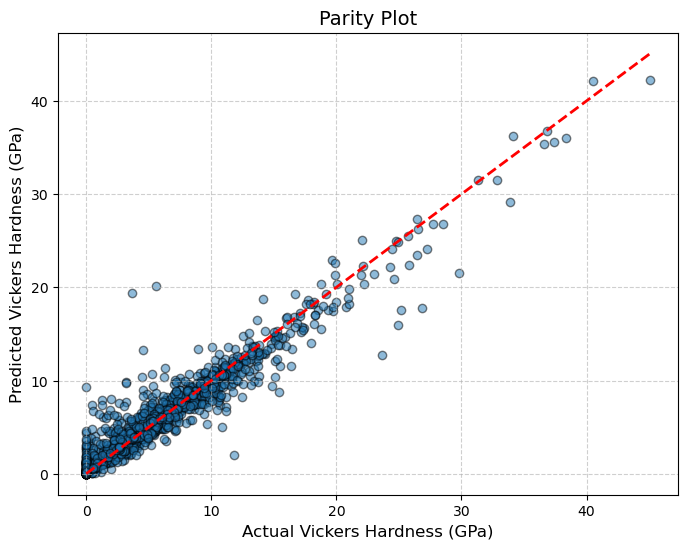

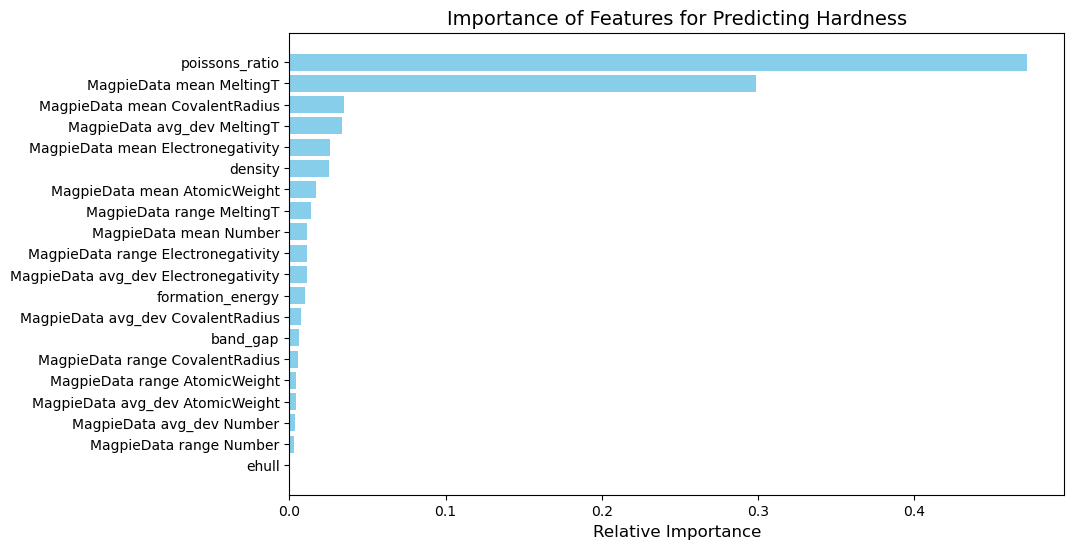

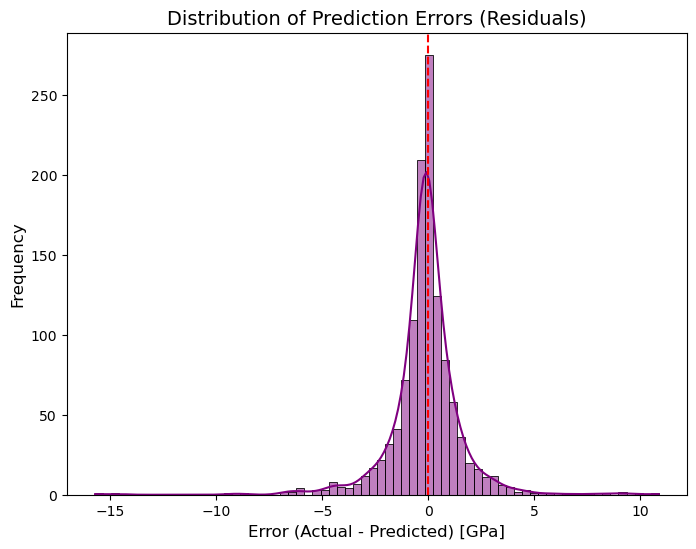

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor

df = pd.read_csv("mp_hardness_dataset4.csv")

df = pd.get_dummies(df, columns=['crystal_system'])
X = df.select_dtypes(include=['number'])
X = X.drop(columns=["vickers_hardness_gpa","shear_modulus", "bulk_modulus"])
y = df['vickers_hardness_gpa']
print("X data types:", X.dtypes)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=500, random_state=42)
model.fit(X_train, y_train)

predictions = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print(f"Model Performance:")
print(f"Root Mean Squared Error: {rmse:.2f} GPa")
print(f"R² Score: {r2:.2f}")

# Parity Plot (Predicted vs Actual)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, alpha=0.5, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  # Diagonal line

plt.xlabel('Actual Vickers Hardness (GPa)', fontsize=12)
plt.ylabel('Predicted Vickers Hardness (GPa)', fontsize=12)
plt.title('Parity Plot', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Feature Importance Plot
importances = model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title('Importance of Features for Predicting Hardness', fontsize=14)
plt.barh(range(len(indices)), importances[indices], color='skyblue', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance', fontsize=12)
plt.show()

# Residual/Error Histogram
residuals = y_test - predictions
plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True, color='purple')
plt.axvline(0, color='red', linestyle='--')

plt.title('Distribution of Prediction Errors (Residuals)', fontsize=14)
plt.xlabel('Error (Actual - Predicted) [GPa]', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()